In [1]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


🔍 Training Multiclass CatBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

📊 Classification Report:
                precision    recall  f1-score   support

         Major       0.83      0.72      0.77       585
         Minor       0.60      0.05      0.10        57
      Moderate       0.79      0.86      0.82      1290
No Interaction       0.96      0.95      0.95      2211
       Unknown       0.85      0.88      0.87       473

      accuracy                           0.88      4616
     macro avg       0.80      0.69      0.70      4616
  weighted avg       0.88      0.88      0.87      4616



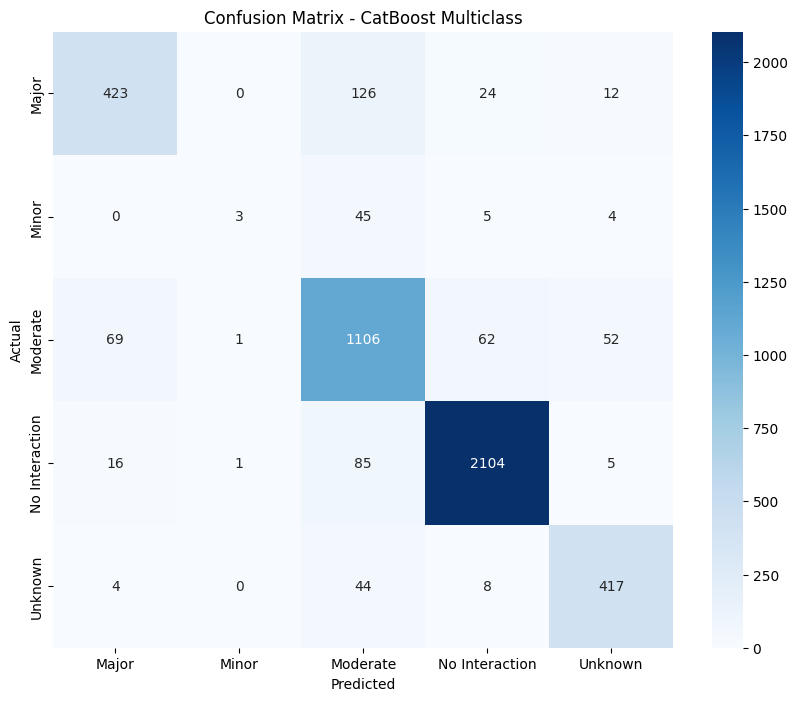

In [2]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ====================== LOAD DATA ======================
df = pd.read_csv('DDinter_with_negatives.csv')

df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

# ====================== CLEAN ======================
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level'])
df = df.drop_duplicates()

# ====================== ENCODE TARGET ======================
le = LabelEncoder()
df['Level_encoded'] = le.fit_transform(df['Level'])
class_names = le.classes_

X = df[['Drug_A', 'Drug_B']]
y = df['Level_encoded']

cat_features = [0, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====================== MODEL ======================
model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_state=42,
    verbose=0
)

# ====================== PARAM SEARCH ======================
param_dist = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 400, 600],
    'l2_leaf_reg': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=15,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("🔍 Training Multiclass CatBoost...")
random_search.fit(X_train, y_train, cat_features=cat_features)

best_model = random_search.best_estimator_

# ====================== EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - CatBoost Multiclass")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [3]:
# ====================== ADDITIONAL METRICS: Overall Precision/Recall/F1 ======================

from sklearn.metrics import precision_score, recall_score, f1_score

# Overall (macro & weighted) Precision, Recall, and F1
print("\n=== Overall Metrics (Tuned Model) ===")

# Macro = unweighted average across classes
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1 Score  : {f1_macro:.4f}")

# Weighted = average weighted by class support (most commonly used "total" score)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1 Score  : {f1_weighted:.4f}")


=== Overall Metrics (Tuned Model) ===
Macro Precision : 0.8038
Macro Recall    : 0.6933
Macro F1 Score  : 0.7016
Weighted Precision : 0.8766
Weighted Recall    : 0.8780
Weighted F1 Score  : 0.8736


In [4]:
# ====================== STEP 8: SAVE THE FULL PIPELINE ======================
# Save the complete fitted pipeline (encoder + scaler + rf)
# This allows you to make predictions directly on new raw Drug_A / Drug_B pairs
import joblib
joblib.dump(best_model, 'ddi_CB_pipeline.pkl')

print("\n✅ Full pipeline saved successfully as 'ddi_CB_pipeline.pkl'")
print("   You can load it later with: pipeline = joblib.load('ddi_CB_pipeline.pkl')")
print("   Then use: predictions = pipeline.predict(new_data)")


✅ Full pipeline saved successfully as 'ddi_CB_pipeline.pkl'
   You can load it later with: pipeline = joblib.load('ddi_CB_pipeline.pkl')
   Then use: predictions = pipeline.predict(new_data)


In [5]:
# ====================== OVERALL METRICS (Multiclass) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Micro-averaged = "overall" / global metrics (sums all TP/FP/FN across classes)
# This is what most people mean by "overall" when they don't want macro or weighted
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall    = recall_score(y_test, y_pred, average='micro')
f1        = f1_score(y_test, y_pred, average='micro')

print("\n" + "="*60)
print("📊 OVERALL METRICS (Multiclass - Micro Averaged)")
print("="*60)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*60)


📊 OVERALL METRICS (Multiclass - Micro Averaged)
Accuracy  : 0.8780  (87.80%)
Precision : 0.8780
Recall    : 0.8780
F1-Score  : 0.8780
